In [67]:
import os
import sys
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, recall_score, roc_auc_score, roc_curve, auc

In [68]:
ROOT_DIR = os.getcwd()
DATA_DIR = os.path.join(ROOT_DIR, "..", "data")
RESULTS_DIR = os.path.join(ROOT_DIR, "..", "results")
meta = pd.read_csv(os.path.join(DATA_DIR, "participants.tsv"), sep="\t")

In [69]:
meta.head()

,participant_id,Gender,Age,Group,MMSE
0,sub-001,F,57,A,16
1,sub-002,F,78,A,22
2,sub-003,M,70,A,14
3,sub-004,F,67,A,20
4,sub-005,M,70,A,22


EEGNet AD vs. CN classification

In [70]:
# Load results from EEGNet AD vs CN classification
file_path = "EEGNet_A_C/C_A/all_results.pkl"

with open(os.path.join(RESULTS_DIR, file_path), "rb") as f:
    eegnet_ad = pickle.load(f)

In [71]:
# Check keys in results
eegnet_ad.keys()

dict_keys(['meta_data', 'outer_folds', 'subject_metadata'])

In [72]:
eegnet_ad["outer_folds"]

[{'outer_fold': 1,
  'test_subject_id': 'sub-001',
  'best_trial_number': 10,
  'best_params': {'F1': 14,
   'D': 1,
   'dropoutRate': 0.25,
   'kernLength': 64,
   'dropoutType': 'Dropout',
   'learning_rate': 6.89927726469809e-05,
   'optimizer': 'adam',
   'batch_size': 128},
  'best_epochs': 4,
  'trained_epochs': 16,
  'inner_model_filepath': '/home/u961155/thesis_codes/results/EEGNet_A_C/C_A/best_model_outer_fold_1.keras',
  'val_loss': 0.6062037944793701,
  'val_accuracy': 0.7338481545448303,
  'test_accuracy': 1.0,
  'true_labels': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
      

In [73]:
# Check fold metadata
eegnet_ad["meta_data"]

{'model_name': 'EEGNet_A_C',
 'class_names': ['C', 'A'],
 'label_map': {'A': 1, 'C': 0},
 'epoch_duration': 4,
 'sampling_rate': 128,
 'chans': 19,
 'samples': 512}

In [74]:
# Check the number of saved folds
print(len(eegnet_ad["outer_folds"]))

65


In [75]:
# Check keys in outer folds
eegnet_ad["outer_folds"][0].keys()

dict_keys(['outer_fold', 'test_subject_id', 'best_trial_number', 'best_params', 'best_epochs', 'trained_epochs', 'inner_model_filepath', 'val_loss', 'val_accuracy', 'test_accuracy', 'true_labels', 'pred_probs', 'pred_labels'])

In [76]:
# Check fold results
for fold in eegnet_ad["outer_folds"]:
    print(fold["outer_fold"], fold["test_subject_id"], fold["test_accuracy"])

1 sub-001 1.0
2 sub-002 0.25316455696202533
3 sub-003 0.7368421052631579
4 sub-004 1.0
5 sub-005 0.9875311720698254
6 sub-006 0.09841269841269841
7 sub-007 1.0
8 sub-008 0.9746835443037974
9 sub-009 0.40327868852459015
10 sub-010 0.514866979655712
11 sub-011 0.4490861618798956
12 sub-012 0.37727272727272726
13 sub-013 0.9401913875598086
14 sub-014 0.9527896995708155
15 sub-015 0.49443207126948774
16 sub-016 0.9876288659793815
17 sub-017 1.0
18 sub-018 1.0
19 sub-019 0.7467248908296943
20 sub-020 0.9838337182448037
21 sub-021 0.25925925925925924
22 sub-022 0.9951100244498777
23 sub-023 0.9375
24 sub-024 1.0
25 sub-025 0.04105571847507331
26 sub-026 1.0
27 sub-027 1.0
28 sub-028 1.0
29 sub-029 1.0
30 sub-030 1.0
31 sub-031 0.4059233449477352
32 sub-032 0.9445843828715366
33 sub-033 0.9943019943019943
34 sub-034 0.9958592132505176
35 sub-035 1.0
36 sub-036 0.3126491646778043
37 sub-037 0.6640826873385013
38 sub-038 0.7454954954954955
39 sub-039 0.8160377358490566
40 sub-040 0.844074844074

In [77]:
# Check one specific fold 
fold_idx = 0
fold = eegnet_ad["outer_folds"][fold_idx]

y_true = fold["true_labels"]
y_pred = fold["pred_labels"]
y_prob = fold["pred_probs"]

print("True labels:", y_true[:10])
print("Predicted labels:", y_pred[:10])
print("Predicted probabilities:", y_prob[:10])

True labels: [1 1 1 1 1 1 1 1 1 1]
Predicted labels: [1 1 1 1 1 1 1 1 1 1]
Predicted probabilities: [0.6815293  0.6920767  0.69437766 0.6809404  0.718216   0.73593575
 0.71233547 0.72508967 0.7563343  0.7186408 ]


In [78]:
# Append subject metadata to results
eegnet_ad["subject_metadata"] = {}

for fold in eegnet_ad["outer_folds"]:
    for subject_id in np.unique(fold["test_subject_id"]):
        # print(subject_id)
        subject_meta = meta[meta["participant_id"] == subject_id].iloc[0]
        eegnet_ad["subject_metadata"][subject_id] = {
            "gender": subject_meta["Gender"],
            "age": subject_meta["Age"],
            "group": subject_meta["Group"]
        }

In [79]:
# Check updated metadata
eegnet_ad["subject_metadata"]["sub-001"]

{'gender': 'F', 'age': 57, 'group': 'A'}

In [80]:
# Get test accuracies across folds
test_accuracies = []

for fold in eegnet_ad["outer_folds"]:
    acc = fold["test_accuracy"]
    test_accuracies.append({
        "test_subject_id": fold["test_subject_id"],
        "test_accuracy": acc
    })

df_accuracies = pd.DataFrame(test_accuracies)
df_accuracies.head()

,test_subject_id,test_accuracy
0,sub-001,1.000000
1,sub-002,0.253165
2,sub-003,0.736842
3,sub-004,1.000000
4,sub-005,0.987531


In [81]:
print(df_accuracies["test_accuracy"].mean(), df_accuracies["test_accuracy"].std())

0.7068570434091808 0.3162519917755785


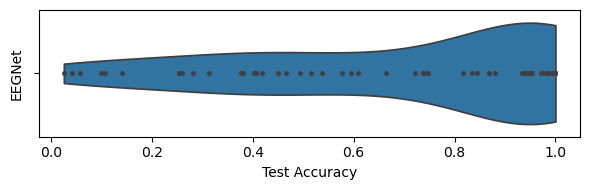

In [82]:
# Violin plot of test accuracies
plt.figure(figsize=(6, 2)) 
sns.violinplot(data=df_accuracies, x="test_accuracy", inner="point", cut=0)
plt.xlabel("Test Accuracy")
plt.ylabel("EEGNet")
plt.tight_layout()
plt.savefig("figures/EEGNet_AD_CN_test_accuracies_violin.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [83]:
# Get predictions and true labels across folds
all_y_true = []
all_y_pred = []
all_y_prob = []

for fold in eegnet_ad["outer_folds"]:
    all_y_true.extend(fold["true_labels"])
    all_y_pred.extend(fold["pred_labels"])
    all_y_prob.extend(fold["pred_probs"])

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)

In [84]:
# Calculate overall metrics
accuracy = accuracy_score(all_y_true, all_y_pred)
f1_score_value = f1_score(all_y_true, all_y_pred)
sensitivity = recall_score(all_y_true, all_y_pred)
specificity = recall_score(all_y_true, all_y_pred, pos_label=0)
roc_auc = roc_auc_score(all_y_true, all_y_prob)
cm = confusion_matrix(all_y_true, all_y_pred)
print("Accuracy:", accuracy)
print("F1 Score:", f1_score_value)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)
print("ROC AUC:", roc_auc)
print("Confusion Matrix:\n", cm)

Accuracy: 0.7071552439116339
F1 Score: 0.7416522548889185
Sensitivity: 0.7682237839327546
Specificity: 0.6333666333666333
ROC AUC: 0.8171267521463883
Confusion Matrix:
 [[ 7608  4404]
 [ 3364 11150]]


In [85]:
# Subject-level predictions and true labels
rows = []

for fold in eegnet_ad["outer_folds"]:
    y_true = fold["true_labels"]
    y_pred = fold["pred_labels"]
    subject_ids = fold["test_subject_id"]

    # Majority vote for subject-level prediction
    pred_majority = np.bincount(y_pred).argmax()
    true_label = y_true

    rows.append({
        "subject_id": subject_ids,
        "true_label": true_label[0],
        "pred_label": pred_majority
    })

df_subjects = pd.DataFrame(rows)

In [86]:
df_subjects.head()

,subject_id,true_label,pred_label
0,sub-001,1,1
1,sub-002,1,0
2,sub-003,1,1
3,sub-004,1,1
4,sub-005,1,1


In [87]:
cm_subjects = confusion_matrix(df_subjects["true_label"], df_subjects["pred_label"])
print("Subject-level Confusion Matrix:\n", cm_subjects)

Subject-level Confusion Matrix:
 [[20  9]
 [10 26]]


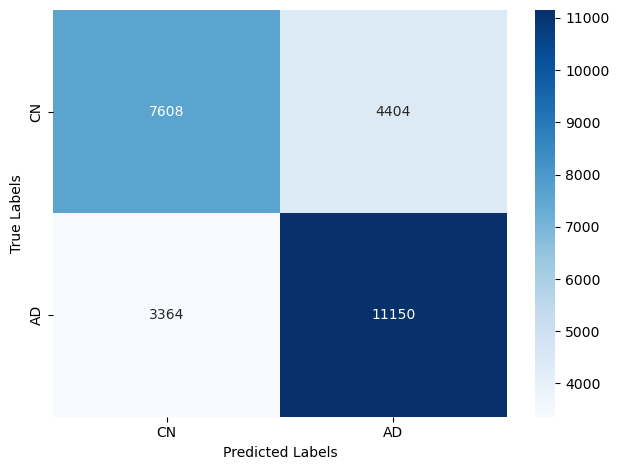

In [88]:
# Plot sample-level confusion matrix
class_names = ["CN", "AD"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.savefig("figures/EEGNet_AD_CN_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

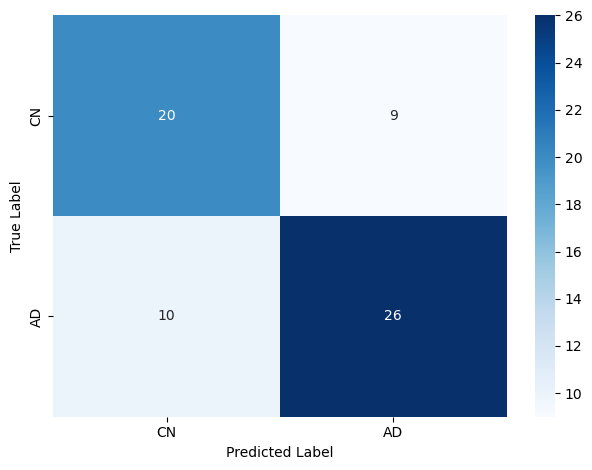

In [89]:
# Plot subject-level confusion matrix
sns.heatmap(cm_subjects, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("figures/EEGNet_AD_CN_subject_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

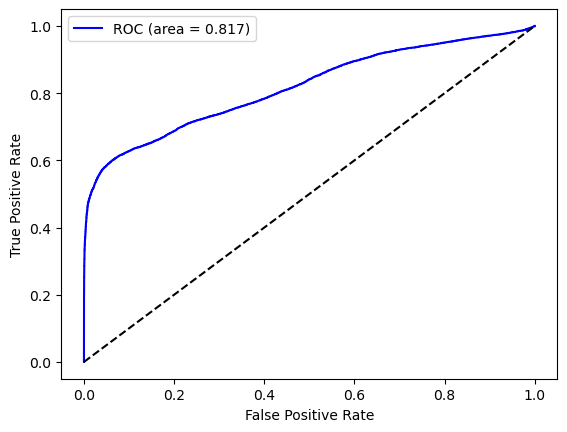

In [90]:
# Plot AUC ROC curve
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_prob)
auc_val = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color="blue", label=f"ROC (area = {auc_val:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='best')
plt.savefig("figures/EEGNet_AD_CN_ROC_curve.pdf", dpi=300, bbox_inches="tight")
plt.show()

EEGNet FTD vs. CN classification

In [91]:
# Load results from EEGNet FTD vs CN classification
with open(os.path.join(RESULTS_DIR, "EEGNet_F_C/C_F/all_results.pkl"), "rb") as f:
    eegnet_ftd = pickle.load(f)

In [92]:
# Check fold results 
for fold in eegnet_ftd["outer_folds"]:
    print(fold["outer_fold"], fold["test_subject_id"], fold["test_accuracy"])

1 sub-037 1.0
2 sub-038 0.6936936936936937
3 sub-039 0.9245283018867925
4 sub-040 0.7858627858627859
5 sub-041 0.9366515837104072
6 sub-042 0.9645833333333333
7 sub-043 0.25181598062953997
8 sub-044 0.9749430523917996
9 sub-045 0.01179245283018868
10 sub-046 0.8613333333333333
11 sub-047 0.9427860696517413
12 sub-048 0.8661257606490872
13 sub-049 1.0
14 sub-050 0.3832923832923833
15 sub-051 0.8933333333333333
16 sub-052 0.6358839050131926
17 sub-053 0.9794344473007712
18 sub-054 0.9496402877697842
19 sub-055 0.874384236453202
20 sub-056 0.9543147208121827
21 sub-057 0.9899244332493703
22 sub-058 0.9787798408488063
23 sub-059 0.04846938775510204
24 sub-060 0.5978552278820375
25 sub-061 0.1775
26 sub-062 0.28348214285714285
27 sub-063 0.6184538653366584
28 sub-064 1.0
29 sub-065 0.5895691609977324
30 sub-066 0.9047619047619048
31 sub-067 0.46875
32 sub-068 0.14385964912280702
33 sub-069 0.9337539432176656
34 sub-070 0.008403361344537815
35 sub-071 0.5357142857142857
36 sub-072 1.0
37 sub

In [93]:
# Check one fold results
fold_idx = 0
fold = eegnet_ftd["outer_folds"][fold_idx]

y_true = fold["true_labels"]
y_pred = fold["pred_labels"]
y_prob = fold["pred_probs"]

print("True labels:", y_true[:10])
print("Predicted labels:", y_pred[:10])
print("Predicted probabilities:", y_prob[:10])

True labels: [0 0 0 0 0 0 0 0 0 0]
Predicted labels: [0 0 0 0 0 0 0 0 0 0]
Predicted probabilities: [0.44469136 0.44542128 0.45801425 0.48206866 0.46989244 0.47374836
 0.45696595 0.44376737 0.44228467 0.47025478]


In [94]:
# Append subject metadata to results
eegnet_ftd["subject_metadata"] = {}

for fold in eegnet_ftd["outer_folds"]:
    for subject_id in np.unique(fold["test_subject_id"]):
        subject_meta = meta[meta["participant_id"] == subject_id].iloc[0]
        eegnet_ftd["subject_metadata"][subject_id] = {
            "gender": subject_meta["Gender"],
            "age": subject_meta["Age"],
            "group": subject_meta["Group"]
        }

In [95]:
# Check updated metadata
eegnet_ftd["subject_metadata"]["sub-060"]

{'gender': 'F', 'age': 71, 'group': 'C'}

In [96]:
# Get test accuracies across folds
test_accuracies = []

for fold in eegnet_ftd["outer_folds"]:
    acc = fold["test_accuracy"]
    test_accuracies.append({
        "test_subject_id": fold["test_subject_id"],
        "test_accuracy": acc
    })

df_accuracies = pd.DataFrame(test_accuracies)
df_accuracies.head()

,test_subject_id,test_accuracy
0,sub-037,1.000000
1,sub-038,0.693694
2,sub-039,0.924528
3,sub-040,0.785863
4,sub-041,0.936652


In [97]:
print(df_accuracies["test_accuracy"].mean(), df_accuracies["test_accuracy"].std())

0.6691228535221766 0.35736405613226463


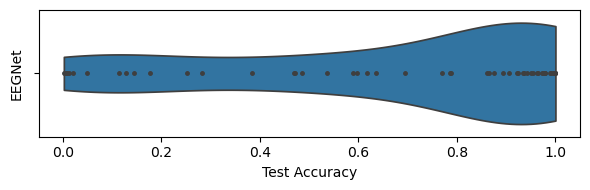

In [98]:
# Violin plot of test accuracies
plt.figure(figsize=(6, 2))
sns.violinplot(data=df_accuracies, x="test_accuracy", inner="point", cut=0)
plt.xlabel("Test Accuracy")
plt.ylabel("EEGNet")
plt.tight_layout()
plt.savefig("figures/EEGNet_FTD_CN_test_accuracies_violin.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [99]:
# Get predictions and true labels across folds
all_y_true = []
all_y_pred = []
all_y_prob = []

for fold in eegnet_ftd["outer_folds"]:
    all_y_true.extend(fold["true_labels"])
    all_y_pred.extend(fold["pred_labels"])
    all_y_prob.extend(fold["pred_probs"])

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)

In [100]:
# Calculate overall metrics
accuracy = accuracy_score(all_y_true, all_y_pred)
f1_score_value = f1_score(all_y_true, all_y_pred)
sensitivity = recall_score(all_y_true, all_y_pred)
specificity = recall_score(all_y_true, all_y_pred, pos_label=0)
roc_auc = roc_auc_score(all_y_true, all_y_prob)
cm = confusion_matrix(all_y_true, all_y_pred)
print("Accuracy:", accuracy)
print("F1 Score:", f1_score_value)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)
print("ROC AUC:", roc_auc)
print("Confusion Matrix:\n", cm)

Accuracy: 0.6754463845319127
F1 Score: 0.5994643291940589
Sensitivity: 0.5959816025175503
Specificity: 0.7301032301032301
ROC AUC: 0.7004532323159773
Confusion Matrix:
 [[8770 3242]
 [3338 4924]]


In [101]:
# Subject-level predictions and true labels
rows = []

for fold in eegnet_ftd["outer_folds"]:
    y_true = fold["true_labels"]
    y_pred = fold["pred_labels"]
    subject_ids = fold["test_subject_id"]

    # Majority vote for subject-level prediction
    pred_majority = np.bincount(y_pred).argmax()
    true_label = y_true

    rows.append({
        "subject_id": subject_ids,
        "true_label": true_label[0],
        "pred_label": pred_majority
    })

df_subjects = pd.DataFrame(rows)
df_subjects.head()

,subject_id,true_label,pred_label
0,sub-037,0,0
1,sub-038,0,0
2,sub-039,0,0
3,sub-040,0,0
4,sub-041,0,0


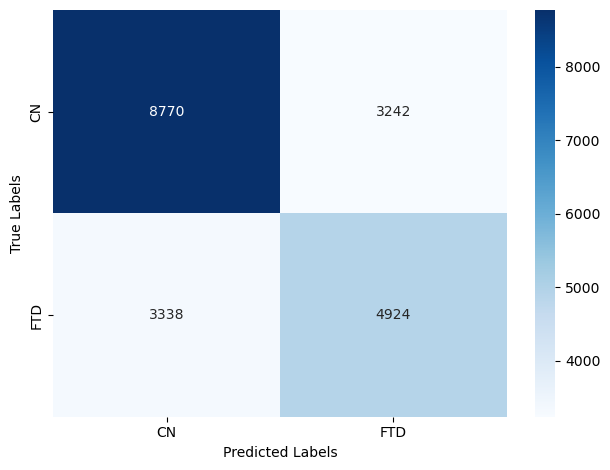

In [102]:
# Plot sample-level confusion matrix
class_names = ["CN", "FTD"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.savefig("figures/EEGNet_FTD_CN_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

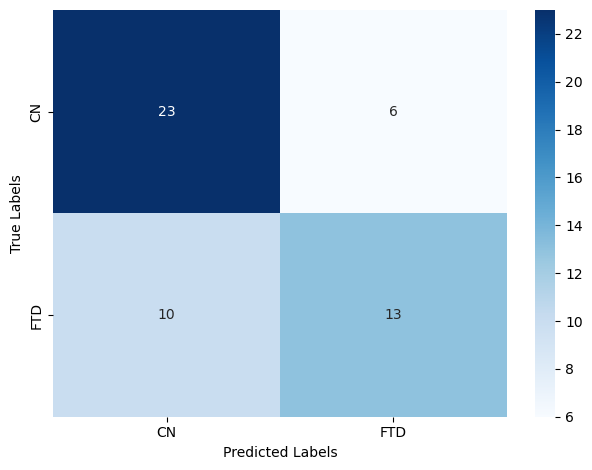

In [103]:
# Plot subject-level confusion matrix
cm_subjects = confusion_matrix(df_subjects["true_label"], df_subjects["pred_label"])
sns.heatmap(cm_subjects, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.savefig("figures/EEGNet_FTD_CN_subject_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

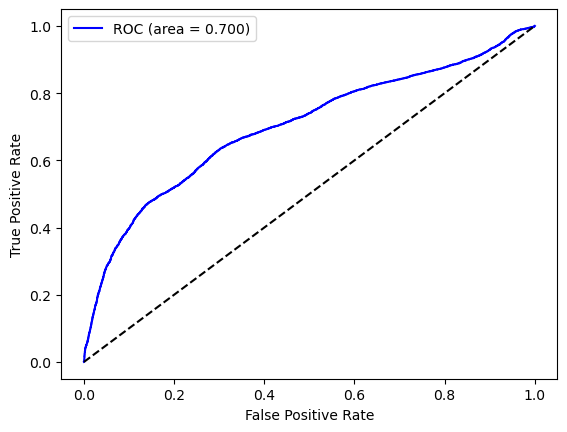

In [104]:
# Plot AUC ROC curve
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_prob)
auc_val = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color="blue", label=f"ROC (area = {auc_val:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='best')
plt.savefig("figures/EEGNet_FTD_CN_ROC_curve.pdf", dpi=300, bbox_inches="tight")
plt.show()

Customised CNN AD vs. FTD classification

In [172]:
file_path = "OptunaCNN/alpha/C_A/all_results.pkl"

with open(os.path.join(RESULTS_DIR, file_path), "rb") as f:
    cnn_ad = pickle.load(f)

In [173]:
# Check fold metadata
cnn_ad["meta_data"]

{'model_name': 'OptunaCNN',
 'class_names': ['C', 'A'],
 'label_map': {'A': 1, 'C': 0},
 'band': 'alpha'}

In [212]:
# Check fold results
for fold in cnn_ad["outer_folds"]:
    print(fold["outer_fold"], fold["test_subject_id"], fold["test_accuracy"])

1 sub-001 1.0
2 sub-002 0.4873417615890503
3 sub-003 0.3135313391685486
4 sub-004 1.0
5 sub-005 0.9800249934196472
6 sub-006 0.37042924761772156
7 sub-007 0.9449541568756104
8 sub-008 0.9949367046356201
9 sub-009 0.7783251404762268
10 sub-010 0.6478873491287231
11 sub-011 0.45430809259414673
12 sub-012 0.7772727012634277
13 sub-013 0.3652694523334503
14 sub-014 0.9205155968666077
15 sub-015 0.3351893126964569
16 sub-016 0.9793601632118225
17 sub-017 0.9452381134033203
18 sub-018 0.5415676832199097
19 sub-019 0.6841530203819275
20 sub-020 0.9157043695449829
21 sub-021 0.6870229244232178
22 sub-022 0.4718826413154602
23 sub-023 0.5342960357666016
24 sub-024 0.9484127163887024
25 sub-025 0.08516886830329895
26 sub-026 0.5173184275627136
27 sub-027 0.9708383679389954
28 sub-028 1.0
29 sub-029 0.9931787252426147
30 sub-030 0.7150635123252869
31 sub-031 0.2685265839099884
32 sub-032 0.8337531685829163
33 sub-033 1.0
34 sub-034 0.8436853289604187
35 sub-035 1.0
36 sub-036 0.9952267408370972
3

In [175]:
# Check one specific fold
fold_idx = 0
fold = cnn_ad["outer_folds"][fold_idx]

y_true = fold["true_labels"]
y_pred = fold["pred_labels"]
y_prob = fold["pred_probs"]

print("True labels:", y_true[:10])
print("Predicted labels:", y_pred[:10])
print("Predicted probabilities:", y_prob[:10])

True labels: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Predicted labels: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Predicted probabilities: [0.7558663  0.7828178  0.8119654  0.76480335 0.76786005 0.7470682
 0.7754144  0.74051094 0.801308   0.7920282 ]


In [176]:
# Append subject metadata to results
cnn_ad["subject_metadata"] = {}

for fold in cnn_ad["outer_folds"]:
    for subject_id in np.unique(fold["test_subject_id"]):
        # print(subject_id)
        subject_meta = meta[meta["participant_id"] == subject_id].iloc[0]
        cnn_ad["subject_metadata"][subject_id] = {
            "gender": subject_meta["Gender"],
            "age": subject_meta["Age"],
            "group": subject_meta["Group"]
        }

In [177]:
# Check updated metadata
cnn_ad["subject_metadata"]["sub-001"]

{'gender': 'F', 'age': 57, 'group': 'A'}

In [211]:
# Get test accuracies across folds
test_accuracies = []

for fold in cnn_ad["outer_folds"]:
    acc = fold["test_accuracy"]
    test_accuracies.append({
        "test_subject_id": fold["test_subject_id"],
        "test_accuracy": acc
    })

df_accuracies = pd.DataFrame(test_accuracies)
df_accuracies.head()

,test_subject_id,test_accuracy
0,sub-001,1.000000
1,sub-002,0.487342
2,sub-003,0.313531
3,sub-004,1.000000
4,sub-005,0.980025


In [179]:
print(df_accuracies["test_accuracy"].mean(), df_accuracies["test_accuracy"].std())

0.6614678264237367 0.29207810847951804


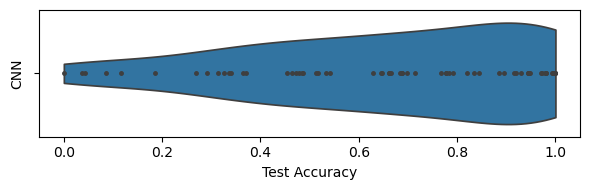

In [180]:
# Violing plot of test accuracies
plt.figure(figsize=(6, 2))
sns.violinplot(data=df_accuracies, x="test_accuracy", inner="point", cut=0)
plt.xlabel("Test Accuracy")
plt.ylabel("CNN")
plt.tight_layout()
plt.savefig("figures/CNN_AD_CN_test_accuracies_violin.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [181]:
# Get predictions and true labels across folds
all_y_true = []
all_y_pred = []
all_y_prob = []

for fold in cnn_ad["outer_folds"]:
    all_y_true.extend(fold["true_labels"])
    all_y_pred.extend(fold["pred_labels"])
    all_y_prob.extend(fold["pred_probs"])

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)

In [184]:
# Calculate overall metrics
accuracy = accuracy_score(all_y_true, all_y_pred)
f1_score_value = f1_score(all_y_true, all_y_pred)
sensitivity = recall_score(all_y_true, all_y_pred)
specificity = recall_score(all_y_true, all_y_pred, pos_label=0)
roc_auc = roc_auc_score(all_y_true, all_y_prob)
cm = confusion_matrix(all_y_true, all_y_pred)
print("Accuracy:", accuracy)
print("F1 Score:", f1_score_value)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)
print("ROC AUC:", roc_auc)
print("Confusion Matrix:\n", cm)

Accuracy: 0.6627121840814787
F1 Score: 0.7034672591904754
Sensitivity: 0.7312213450997966
Specificity: 0.5799425263420932
ROC AUC: 0.7169525788678166
Confusion Matrix:
 [[13925 10086]
 [ 7797 21212]]


In [185]:
# Subject-level predictions and true labels
rows = []

for fold in cnn_ad["outer_folds"]:
    y_true = fold["true_labels"]
    y_pred = fold["pred_labels"]
    subject_ids = fold["test_subject_id"]

    # Majority vote for subject-level prediction
    pred_majority = np.bincount(y_pred.astype(int)).argmax()
    true_label = y_true

    rows.append({
        "subject_id": subject_ids,
        "true_label": true_label[0],
        "pred_label": pred_majority
    })

df_subjects = pd.DataFrame(rows)

In [186]:
cm_subjects = confusion_matrix(df_subjects["true_label"], df_subjects["pred_label"])
print("Subject-level Confusion Matrix:\n", cm_subjects)

Subject-level Confusion Matrix:
 [[18 11]
 [ 9 27]]


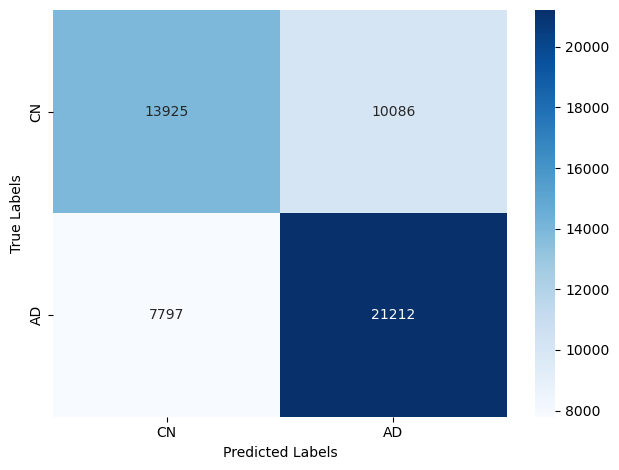

In [187]:
# Plot sample-level confusion matrix
class_names = ["CN", "AD"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.savefig("figures/EEGNet_AD_CN_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

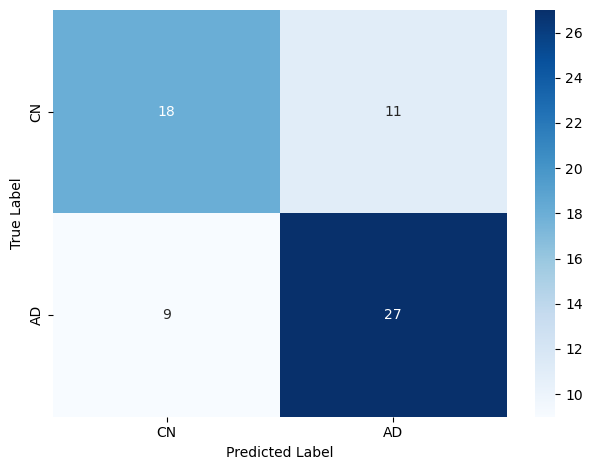

In [189]:
# Plot subject-level confusion matrix
sns.heatmap(cm_subjects, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("figures/CNN_AD_CN_subject_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

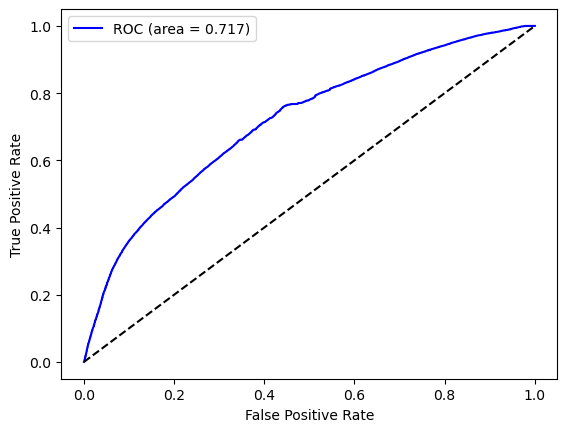

In [190]:
# Plot AUC ROC curve
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_prob)
auc_val = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color="blue", label=f"ROC (area = {auc_val:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='best')
plt.savefig("figures/CNN_AD_CN_ROC_curve.pdf", dpi=300, bbox_inches="tight")
plt.show()

Customised CNN FTD vs. CN classification

In [193]:
file_path = "OptunaCNN/alpha/C_F/all_results.pkl"

with open(os.path.join(RESULTS_DIR, file_path), "rb") as f:
    cnn_ftd = pickle.load(f)

In [194]:
# Check fold metadata
cnn_ftd["meta_data"]

{'model_name': 'OptunaCNN',
 'class_names': ['C', 'F'],
 'label_map': {'F': 1, 'C': 0},
 'band': 'alpha'}

In [210]:
# Check fold results
for fold in cnn_ftd["outer_folds"]:
    print(fold["outer_fold"], fold["test_subject_id"], fold["test_accuracy"])

1 sub-037 0.9547803401947021
2 sub-038 0.4324324429035187
3 sub-039 0.9586777091026306
4 sub-040 0.6237006187438965
5 sub-041 0.22763307392597198
6 sub-042 0.9520833492279053
7 sub-043 0.8292978405952454
8 sub-044 0.7346241474151611
9 sub-045 0.25235849618911743
10 sub-046 0.7946666479110718
11 sub-047 0.85447758436203
12 sub-048 0.9675456285476685
13 sub-049 0.5096524953842163
14 sub-050 0.9754299521446228
15 sub-051 0.35466668009757996
16 sub-052 0.5455746650695801
17 sub-053 0.9111968874931335
18 sub-054 0.9856114983558655
19 sub-055 0.7348951697349548
20 sub-056 0.7804568409919739
21 sub-057 0.404791921377182
22 sub-058 0.011952191591262817
23 sub-059 0.020408162847161293
24 sub-060 0.3181208074092865
25 sub-061 0.05624999850988388
26 sub-062 0.8692737221717834
27 sub-063 0.5493133664131165
28 sub-064 0.9846153855323792
29 sub-065 0.5766174793243408
30 sub-066 0.4157509207725525
31 sub-067 0.964062511920929
32 sub-068 0.019298246130347252
33 sub-069 0.2132701426744461
34 sub-070 0.

In [196]:
# Check one specific fold
fold_idx = 0
fold = cnn_ftd["outer_folds"][fold_idx]

y_true = fold["true_labels"]
y_pred = fold["pred_labels"]
y_prob = fold["pred_probs"]

print("True labels:", y_true[:10])
print("Predicted labels:", y_pred[:10])
print("Predicted probabilities:", y_prob[:10])

True labels: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Predicted labels: [0. 0. 0. 1. 0. 0. 1. 0. 0. 0.]
Predicted probabilities: [0.03700762 0.09101557 0.16627727 0.5006581  0.49043074 0.47884578
 0.54815084 0.4530346  0.3729469  0.31466076]


In [197]:
# Append subject metadata to results
cnn_ftd["subject_metadata"] = {}

for fold in cnn_ftd["outer_folds"]:
    for subject_id in np.unique(fold["test_subject_id"]):
        # print(subject_id)
        subject_meta = meta[meta["participant_id"] == subject_id].iloc[0]
        cnn_ftd["subject_metadata"][subject_id] = {
            "gender": subject_meta["Gender"],
            "age": subject_meta["Age"],
            "group": subject_meta["Group"]
        }

In [198]:
# Check updated metadata
cnn_ftd["subject_metadata"]["sub-060"]

{'gender': 'F', 'age': 71, 'group': 'C'}

In [213]:
# Get test accuracies across folds
test_accuracies = []

for fold in cnn_ftd["outer_folds"]:
    acc = fold["test_accuracy"]
    test_accuracies.append({
        "test_subject_id": fold["test_subject_id"],
        "test_accuracy": acc
    })

df_accuracies = pd.DataFrame(test_accuracies)
df_accuracies.head()

,test_subject_id,test_accuracy
0,sub-037,0.954780
1,sub-038,0.432432
2,sub-039,0.958678
3,sub-040,0.623701
4,sub-041,0.227633


In [200]:
print(df_accuracies["test_accuracy"].mean(), df_accuracies["test_accuracy"].std())

0.5166237188521057 0.3412785257894965


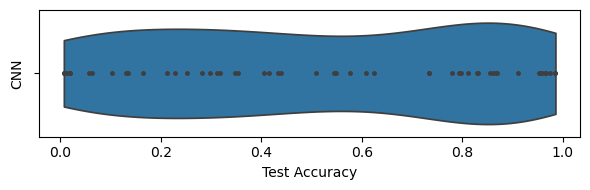

In [201]:
# Violing plot of test accuracies
plt.figure(figsize=(6, 2))
sns.violinplot(data=df_accuracies, x="test_accuracy", inner="point", cut=0)
plt.xlabel("Test Accuracy")
plt.ylabel("CNN")
plt.tight_layout()
plt.savefig("figures/CNN_FTD_CN_test_accuracies_violin.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [202]:
# Get predictions and true labels across folds
all_y_true = []
all_y_pred = []
all_y_prob = []

for fold in cnn_ftd["outer_folds"]:
    all_y_true.extend(fold["true_labels"])
    all_y_pred.extend(fold["pred_labels"])
    all_y_prob.extend(fold["pred_probs"])

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)

In [203]:
# Calculate overall metrics
accuracy = accuracy_score(all_y_true, all_y_pred)
f1_score_value = f1_score(all_y_true, all_y_pred)
sensitivity = recall_score(all_y_true, all_y_pred)
specificity = recall_score(all_y_true, all_y_pred, pos_label=0)
roc_auc = roc_auc_score(all_y_true, all_y_prob)
cm = confusion_matrix(all_y_true, all_y_pred)
print("Accuracy:", accuracy)
print("F1 Score:", f1_score_value)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)
print("ROC AUC:", roc_auc)
print("Confusion Matrix:\n", cm)

Accuracy: 0.5251597936872239
F1 Score: 0.3861932561329633
Sensitivity: 0.366626287098728
Specificity: 0.6341676731498064
ROC AUC: 0.5274510640325587
Confusion Matrix:
 [[15227  8784]
 [10457  6053]]


In [205]:
# Subject-level predictions and true labels
rows = []

for fold in cnn_ftd["outer_folds"]:
    y_true = fold["true_labels"]
    y_pred = fold["pred_labels"]
    subject_ids = fold["test_subject_id"]

    # Majority vote for subject-level prediction
    pred_majority = np.bincount(y_pred.astype(int)).argmax()
    true_label = y_true

    rows.append({
        "subject_id": subject_ids,
        "true_label": true_label[0],
        "pred_label": pred_majority
    })

df_subjects = pd.DataFrame(rows)

In [206]:
cm_subjects = confusion_matrix(df_subjects["true_label"], df_subjects["pred_label"])
print("Subject-level Confusion Matrix:\n", cm_subjects)

Subject-level Confusion Matrix:
 [[20  9]
 [16  7]]


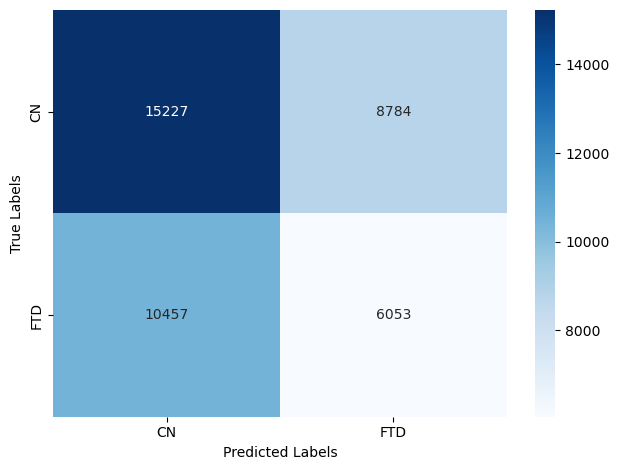

In [207]:
# Plot sample-level confusion matrix
class_names = ["CN", "FTD"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.savefig("figures/EEGNet_AD_CN_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

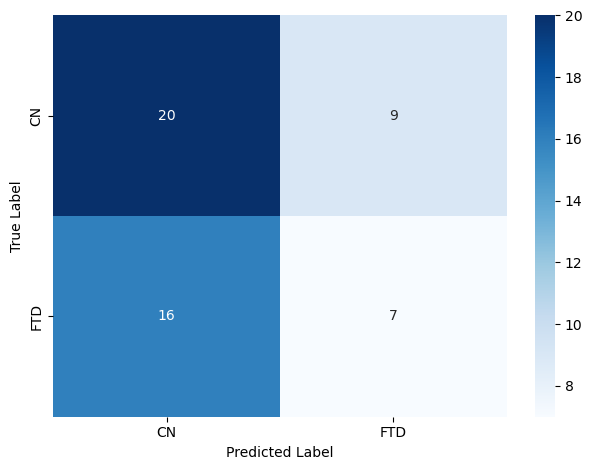

In [208]:
# Plot subject-level confusion matrix
sns.heatmap(cm_subjects, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("figures/CNN_FTD_CN_subject_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

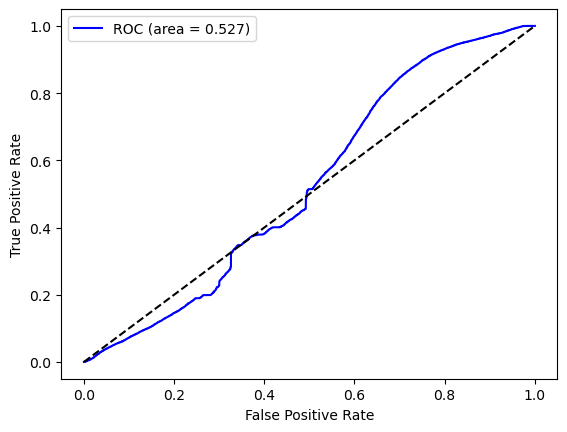

In [209]:
# Plot AUC ROC curve
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_prob)
auc_val = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color="blue", label=f"ROC (area = {auc_val:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='best')
plt.savefig("figures/CNN_FTD_CN_ROC_curve.pdf", dpi=300, bbox_inches="tight")
plt.show()